In [4]:
!pip install kaggle


In [5]:
!pip install opendatasets

In [6]:
!kaggle datasets downlode -d tekbahadurkshetri/landslide4sense

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [7]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tekbahadurkshetri/landslide4sense/data")

Skipping, found downloaded files in "./landslide4sense" (use force=True to force download)


In [8]:
!pip install tensorflow h5py opencv-python

In [9]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [11]:
IMAGE_PATH = "/content/landslide4sense/TrainData/img/"
MASK_PATH = "/content/landslide4sense/TrainData/mask/"

In [13]:
image_files = sorted(os.listdir(IMAGE_PATH))
mask_files = sorted(os.listdir(MASK_PATH))

print("Total Images:", len(image_files))
print("Total Masks:", len(mask_files))

Total Images: 3799
Total Masks: 3799


In [1]:
import os
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [2]:
#paths
IMAGE_PATH = "/content/landslide4sense/TrainData/img/"
MASK_PATH = "/content/landslide4sense/TrainData/mask/"


In [3]:
image_files = sorted(os.listdir(IMAGE_PATH))
mask_files = sorted(os.listdir(MASK_PATH))

print(len(image_files))
print(len(mask_files))

3799
3799


In [4]:
#train/test split
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.2,
    random_state=42
)

In [5]:
#data generation
def data_generator(img_list, mask_list, batch_size):

    while True:

        for i in range(0, len(img_list), batch_size):

            batch_imgs = img_list[i:i+batch_size]
            batch_masks = mask_list[i:i+batch_size]

            images = []
            masks = []

            for img_file, mask_file in zip(batch_imgs, batch_masks):

                with h5py.File(IMAGE_PATH + img_file, 'r') as hf:
                    image = hf['img'][:]

                with h5py.File(MASK_PATH + mask_file, 'r') as hf:
                    mask = hf['mask'][:]

                image = image / np.max(image)

                mask = np.expand_dims(mask, axis=-1)

                images.append(image)
                masks.append(mask)

            yield np.array(images), np.array(masks)

In [6]:
batch_size = 4

train_generator = data_generator(
    train_imgs,
    train_masks,
    batch_size
)

test_generator = data_generator(
    test_imgs,
    test_masks,
    batch_size
)

In [7]:
#smaller cnn model
inputs = Input((128,128,14))

c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
p1 = MaxPooling2D()(c1)

c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
p2 = MaxPooling2D()(c2)

c3 = Conv2D(64,3,activation='relu',padding='same')(p2)

u1 = UpSampling2D()(c3)
u1 = concatenate([u1,c2])

u2 = UpSampling2D()(u1)
u2 = concatenate([u2,c1])

outputs = Conv2D(1,1,activation='sigmoid')(u2)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 14)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,032 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ concatenate[0][0] │
│ (UpSampling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 112)              │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        113 │ concatenate_1[0]… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,281 (98.75 KB)

 Trainable params: 25,281 (98.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#training
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_imgs)//batch_size,
    epochs=10
)

Epoch 1/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 146s 188ms/step - accuracy: 0.9803 - loss: 0.0661
Epoch 2/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 130s 172ms/step - accuracy: 0.9844 - loss: 0.0411
Epoch 3/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 143s 188ms/step - accuracy: 0.9854 - loss: 0.0377
Epoch 4/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 131s 172ms/step - accuracy: 0.9859 - loss: 0.0363
Epoch 5/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 130s 171ms/step - accuracy: 0.9863 - loss: 0.0350
Epoch 6/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 133s 175ms/step - accuracy: 0.9867 - loss: 0.0340
Epoch 7/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 126s 166ms/step - accuracy: 0.9870 - loss: 0.0332
Epoch 8/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 145s 191ms/step - accuracy: 0.9872 - loss: 0.0327
Epoch 9/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 127s 167ms/step - accuracy: 0.9873 - loss: 0.0323
Epoch 10/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 128s 169ms/step - accuracy: 0.9875 - loss: 0.0318


In [18]:
model.save("/content/final_landslide_model.keras")

print("Saved Successfully")

Saved Successfully


In [19]:
print(os.listdir("/content"))

['.config', 'landslide4sense', 'final_landslide_model.keras', 'landslide_cnn_model.keras', 'landslide_cnn_model.h5', 'sample_data']


In [12]:
#predictions
test_images, test_masks = next(test_generator)

prediction = model.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step


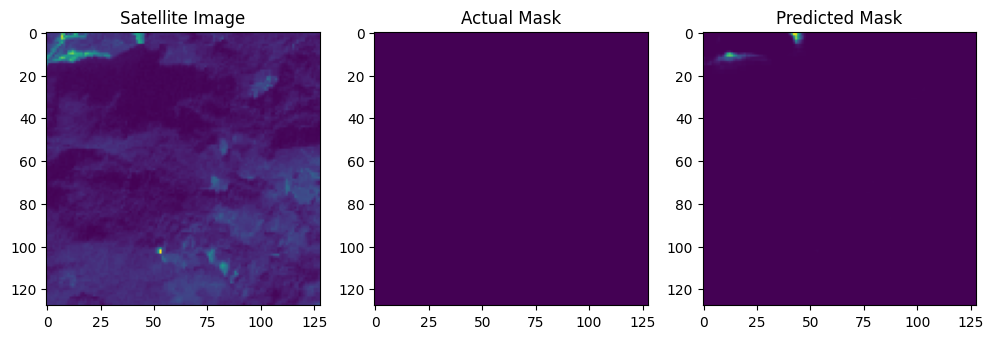

In [13]:
#Visualize Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Satellite Image
plt.subplot(1,3,1)
plt.imshow(test_images[0][:,:,3])
plt.title("Satellite Image")

# Actual Mask
plt.subplot(1,3,2)
plt.imshow(test_masks[0][:,:,0])
plt.title("Actual Mask")

# Predicted Mask
plt.subplot(1,3,3)
plt.imshow(prediction[0][:,:,0])
plt.title("Predicted Mask")

plt.show()

In [14]:
#accuracy
loss, accuracy = model.evaluate(
    test_generator,
    steps=len(test_imgs)//batch_size
)

print("Accuracy:", accuracy)

190/190 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.9875 - loss: 0.0329
Accuracy: 0.9875423908233643


In [20]:
from google.colab import files

files.download("final_landslide_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

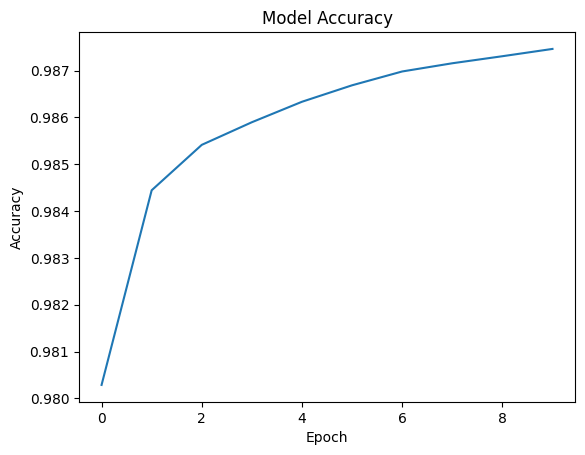

In [21]:
#accuracy graph
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

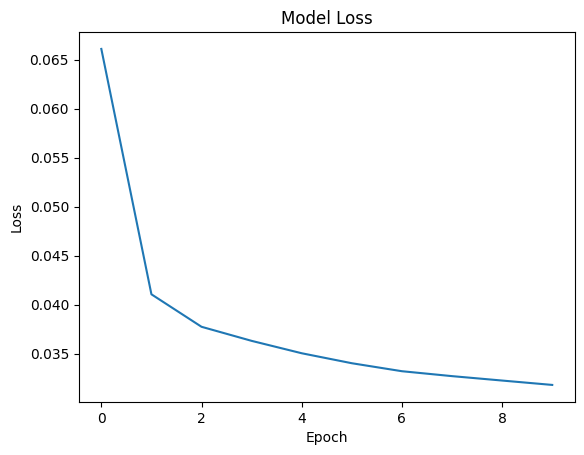

In [23]:
#loss graph
plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()